# Battery Storage Optimization

Given the household's demand and an estimated rooftop solar PV system, schedule battery charge/discharge to minimize electricity cost, and compare against a greedy rule-based heuristic and a no-battery reference.

2026-07-28 09:31:31,628 INFO Battery optimization summary over 314 days:
days_evaluated                      314.000000
no_battery_total_eur               1053.000371
heuristic_total_eur                 707.048922
lp_total_eur                        423.579300
heuristic_savings_pct                32.853877
lp_savings_pct                       59.774060
lp_vs_heuristic_improvement_pct      40.091939
dtype: float64


2026-07-28 09:31:31,791 INFO Saved battery schedule example plot to /Users/despeinaw/Downloads/energy-ai-optimization/reports/figures/battery_schedule_example.png


{'days_evaluated': 314,
 'no_battery_total_eur': np.float64(1053.000370561479),
 'heuristic_total_eur': np.float64(707.0489219301742),
 'lp_total_eur': np.float64(423.5792997819342),
 'heuristic_savings_pct': np.float64(32.85387719729265),
 'lp_savings_pct': np.float64(59.77405976067474),
 'lp_vs_heuristic_improvement_pct': np.float64(40.0919389530212)}

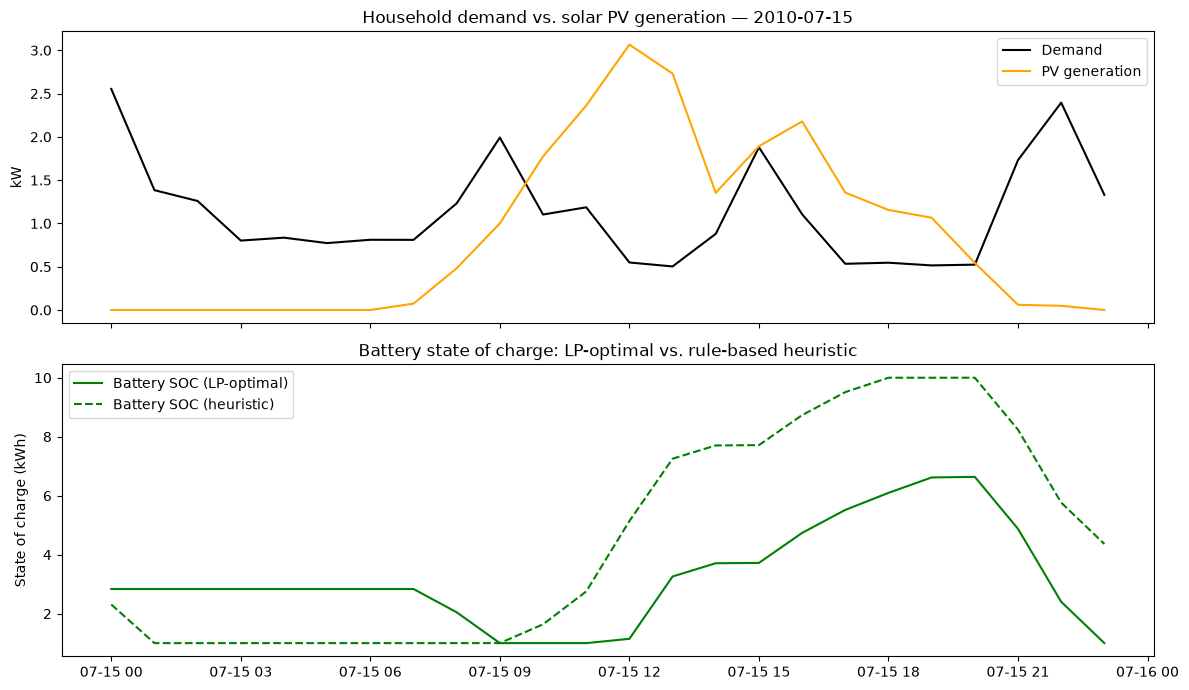

In [1]:
import sys
sys.path.insert(0, '..')
from src.run_battery_optimization import main

summary, totals = main()
summary

## Results over the full test period (314 days)

- **No battery** (PV self-consumption only): reference cost
- **Heuristic** (greedy: charge from PV surplus, discharge to cover PV deficit): ~33% savings
- **LP-optimal**: ~60% savings — roughly 40% cheaper than the heuristic alone

<Axes: title={'center': 'Daily electricity cost by strategy'}, xlabel='date'>

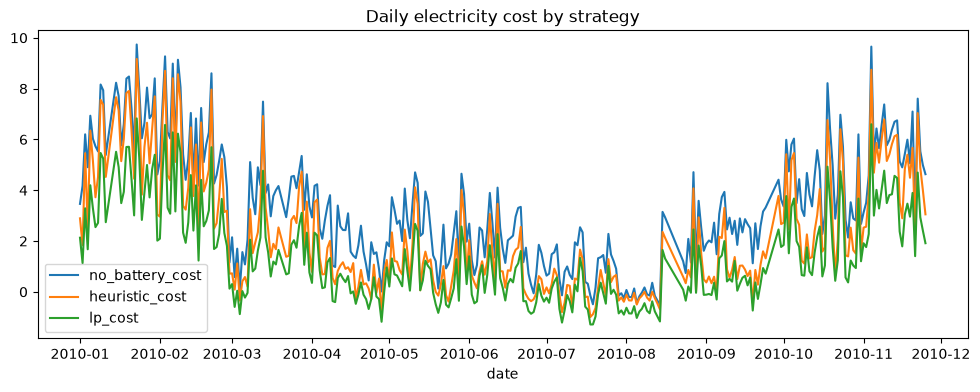

In [2]:
totals.set_index('date')[['no_battery_cost', 'heuristic_cost', 'lp_cost']].plot(
    figsize=(12, 4), title='Daily electricity cost by strategy'
)

## Example day — 2010-07-15

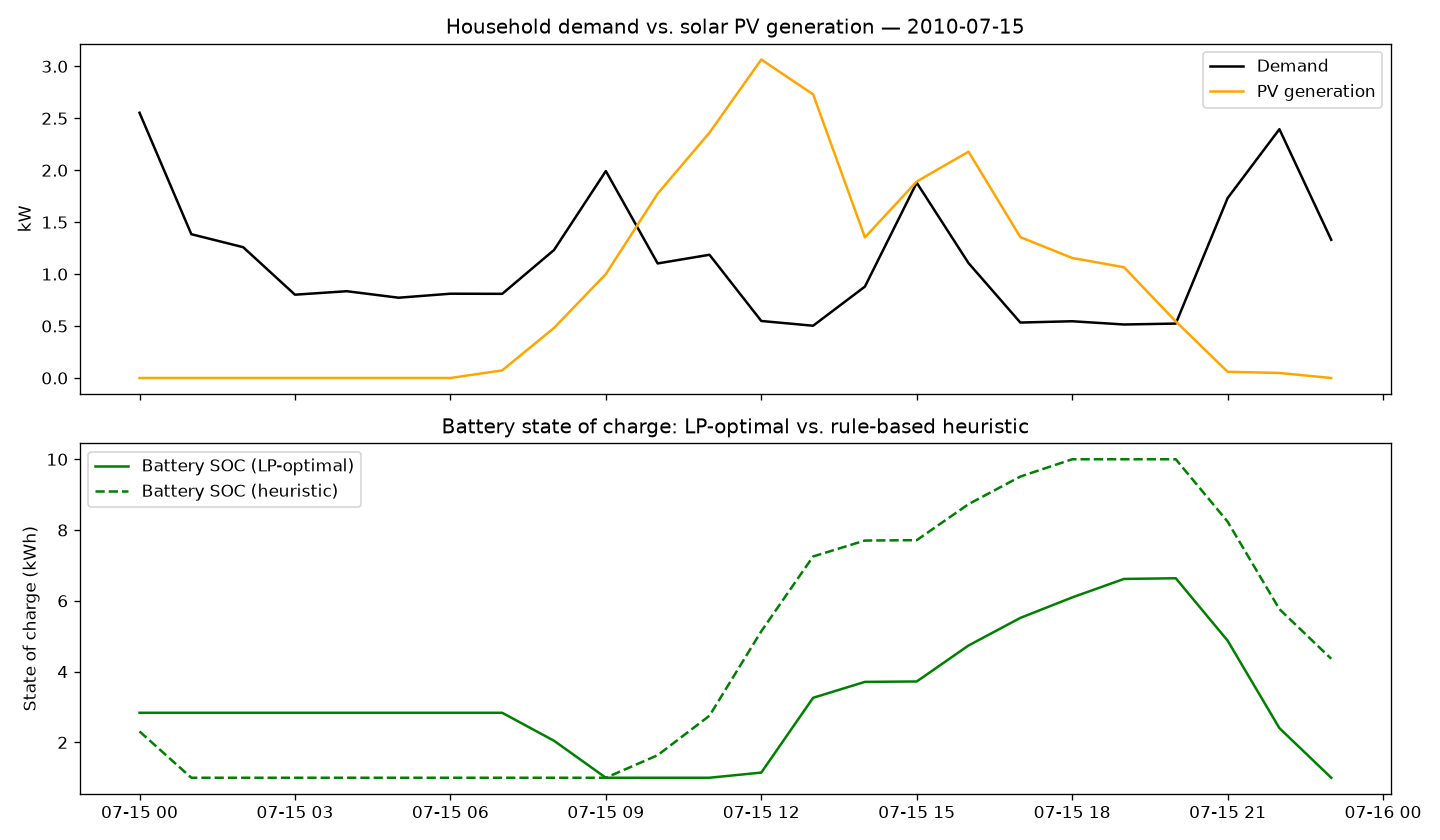

In [3]:
from IPython.display import Image
Image('../reports/figures/battery_schedule_example.png')

## Discussion

On the example day, the LP schedule drains the battery during the early morning hours (when the electricity tariff is flat, so timing doesn't matter for cost) specifically to free up storage headroom before the midday solar peak. This lets it capture more of the surplus solar generation around noon and hold it for the expensive evening peak-price hours, instead of exporting that surplus at the much lower feed-in credit. The rule-based heuristic can't reason about future price changes, so it fills the battery from PV as soon as there's a surplus — leaving less room to capture the biggest midday surplus, and reaching the evening peak with less usable charge.

This is exactly the kind of look-ahead value a linear program provides over a simple rule, and it's the main source of the ~40% additional savings over the heuristic.